# Retail Sales & Demand Forecasting

## Business Problem

Retail businesses need to estimate future sales to support inventory
planning, promotional decisions, and operational planning.

## Objective

The objective of this project is to analyze historical retail sales data
and develop machine learning models to predict daily store sales.

## Approach

The project follows an end-to-end data science workflow:

1. Data understanding
2. Data cleaning
3. Exploratory data analysis
4. Feature engineering
5. SQL-based analysis
6. Machine learning
7. Model evaluation
8. Business interpretation

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

## Load Data

In [2]:
train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")

C:\Users\dell\AppData\Local\Temp\ipykernel_26572\3419646863.py:1: DtypeWarning: Columns (7: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,07/31/2015,5263,555,1,1,0,1
1,2,5,07/31/2015,6064,625,1,1,0,1
2,3,5,07/31/2015,8314,821,1,1,0,1
3,4,5,07/31/2015,13995,1498,1,1,0,1
4,5,5,07/31/2015,4822,559,1,1,0,1


In [4]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
print("Train shape:", train.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [7]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


## Understand the Data

In [8]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [9]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [10]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [11]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [12]:
train.duplicated().sum()

np.int64(0)

In [13]:
store.duplicated().sum()

np.int64(0)

## Merge the Datasets

In [14]:
df = train.merge(
    store,
    on="Store",
    how="left"
)

In [15]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,07/31/2015,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,07/31/2015,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,07/31/2015,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,07/31/2015,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,07/31/2015,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [16]:
df.shape

(1017209, 18)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [18]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

## Handle Closed Stores

Closed stores have zero sales because they were not operating. The initial objective is to predict sales for operating stores, so keeping the analysis focused on open stores makes the target more meaningful.

In [19]:
df["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [20]:
df = df[df["Open"] == 1].copy()

In [21]:
df.shape

(844392, 18)

In [22]:
df["Sales"].describe()

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

## Date Processing

In [23]:
df["Date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

In [25]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [26]:
df[
    [
        "Date",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "WeekOfYear"
    ]
].head()

,Date,Year,Month,Day,DayOfWeek,WeekOfYear
0,2015-07-31,2015,7,31,4,31
1,2015-07-31,2015,7,31,4,31
2,2015-07-31,2015,7,31,4,31
3,2015-07-31,2015,7,31,4,31
4,2015-07-31,2015,7,31,4,31


## Exploratory Data Analysis

### Sales Distribution

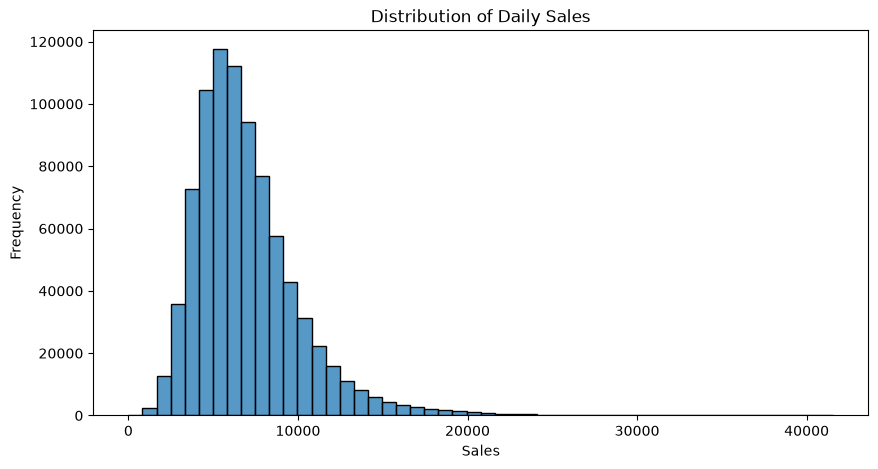

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Sales"], bins=50)

plt.title("Distribution of Daily Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.savefig("../images/sales_distribution.png", bbox_inches='tight')
plt.show()

### Sales Over Time

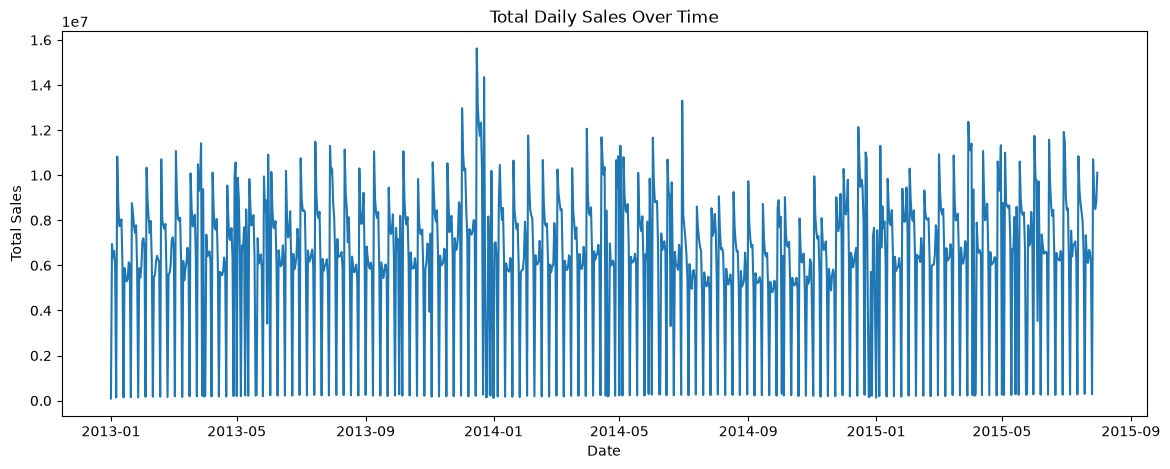

In [28]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales)
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.savefig("../images/sales_over_time.png", bbox_inches='tight')
plt.show()

### Sales by Day of Week

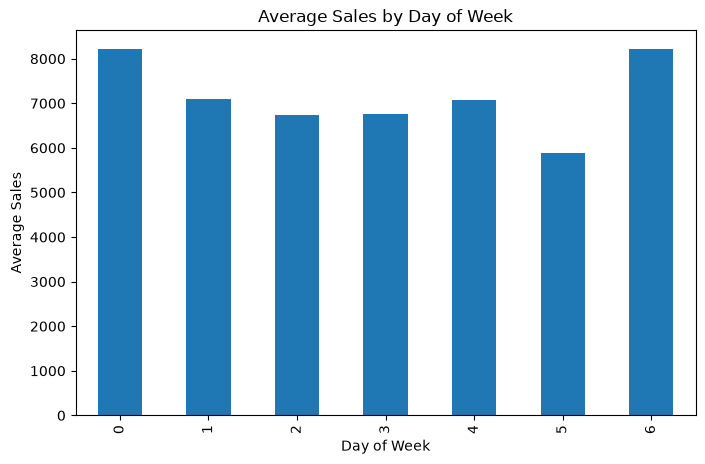

In [29]:
day_sales = df.groupby("DayOfWeek")["Sales"].mean()

plt.figure(figsize=(8, 5))
day_sales.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.savefig("../images/sales_by_day.png", bbox_inches='tight')
plt.show()

### Promotion vs Sales

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


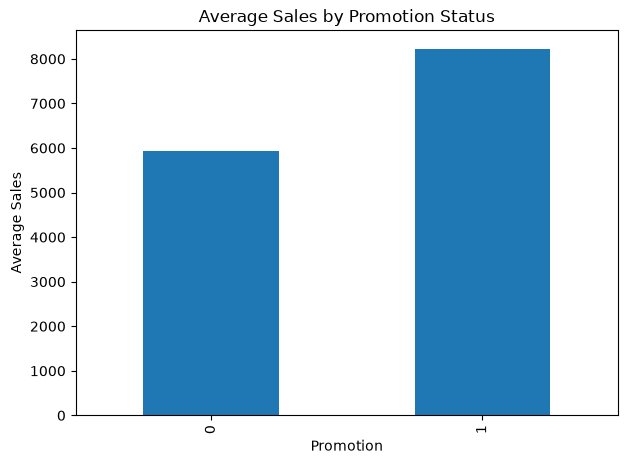

In [30]:
promo_sales = df.groupby("Promo")["Sales"].mean()
print(promo_sales)

plt.figure(figsize=(7, 5))
promo_sales.plot(kind="bar")
plt.title("Average Sales by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.savefig("../images/promotion_analysis.png", bbox_inches='tight')
plt.show()

### Sales by Store Type

StoreType
a     6925.167661
b    10231.407505
c     6932.512755
d     6822.141881
Name: Sales, dtype: float64


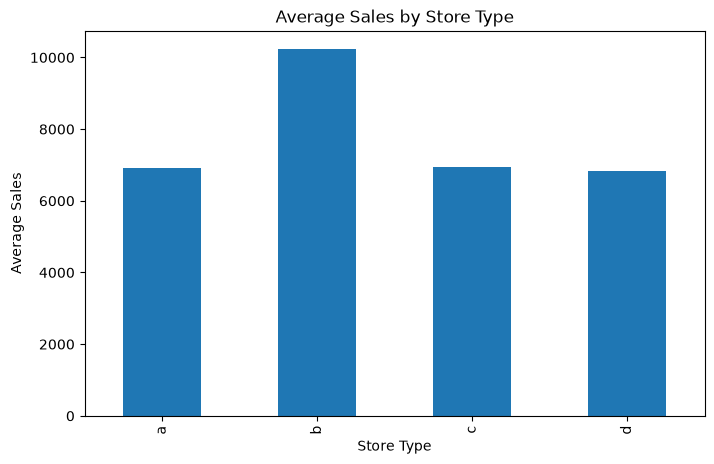

In [31]:
store_type_sales = df.groupby("StoreType")["Sales"].mean()
print(store_type_sales)

plt.figure(figsize=(8, 5))
store_type_sales.plot(kind="bar")
plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

### Monthly Sales

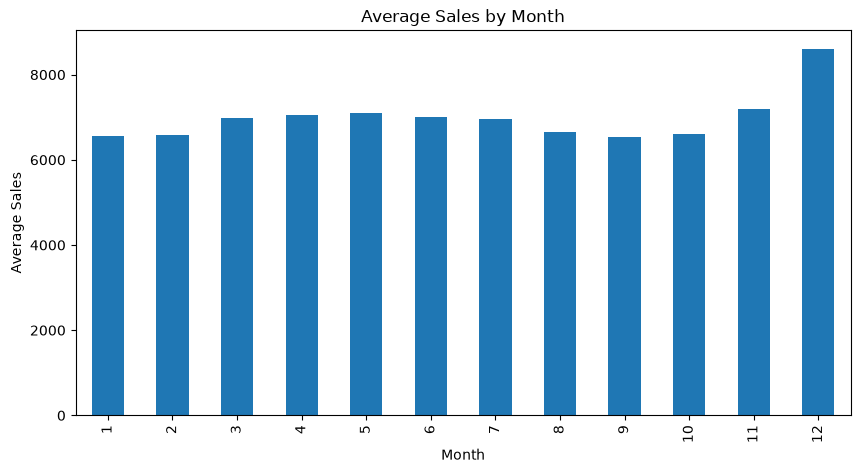

In [32]:
monthly_sales = df.groupby("Month")["Sales"].mean()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="bar")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

### Correlation Analysis

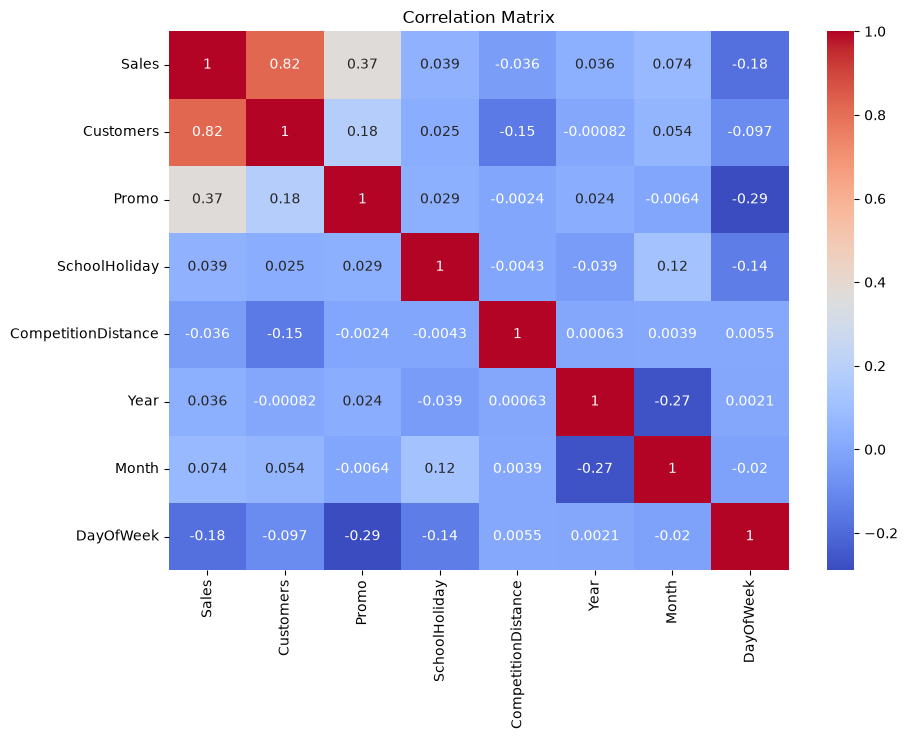

In [33]:
numeric_cols = [
    "Sales",
    "Customers",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "Year",
    "Month",
    "DayOfWeek"
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

## Feature Selection

In [34]:
features = [
    "Store",
    "DayOfWeek",
    "Promo",
    "SchoolHoliday",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Year",
    "Month",
    "Day",
    "WeekOfYear"
]

target = "Sales"

## Categorical Encoding

In [35]:
df_model = pd.get_dummies(
    df[features + [target]],
    columns=["StoreType", "Assortment"],
    drop_first=True
)
df_model.head()

,Store,DayOfWeek,Promo,SchoolHoliday,CompetitionDistance,Year,Month,Day,WeekOfYear,Sales,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c
0,1,4,1,1,1270.0,2015,7,31,31,5263,False,True,False,False,False
1,2,4,1,1,570.0,2015,7,31,31,6064,False,False,False,False,False
2,3,4,1,1,14130.0,2015,7,31,31,8314,False,False,False,False,False
3,4,4,1,1,620.0,2015,7,31,31,13995,False,True,False,False,True
4,5,4,1,1,29910.0,2015,7,31,31,4822,False,False,False,False,False


## Missing Values

In [36]:
df_model.isnull().sum()

Store                     0
DayOfWeek                 0
Promo                     0
SchoolHoliday             0
CompetitionDistance    2186
Year                      0
Month                     0
Day                       0
WeekOfYear                0
Sales                     0
StoreType_b               0
StoreType_c               0
StoreType_d               0
Assortment_b              0
Assortment_c              0
dtype: int64

In [37]:
df_model = df_model.dropna()

## Chronological Train/Test Split

In [38]:
df_model = df_model.sort_values(
    by=["Year", "Month", "Day"]
)

X = df_model.drop(columns=["Sales"])
y = df_model["Sales"]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## Linear Regression Baseline

In [39]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

## Linear Regression Evaluation

In [40]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression MAE:", mae_linear)
print("Linear Regression RMSE:", rmse_linear)
print("Linear Regression R²:", r2_linear)

Linear Regression MAE: 1985.7183875824687
Linear Regression RMSE: 2737.5181552495046
Linear Regression R²: 0.2015281079963115


## Random Forest Regressor

In [41]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

## Random Forest Evaluation

In [42]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 738.0147077925933
Random Forest RMSE: 1098.7271370908447
Random Forest R²: 0.8713750204618992


## Model Comparison

In [43]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R2": [r2_linear, r2_rf]
})
results

,Model,MAE,RMSE,R2
0,Linear Regression,1985.718388,2737.518155,0.201528
1,Random Forest,738.014708,1098.727137,0.871375


## Actual vs Predicted

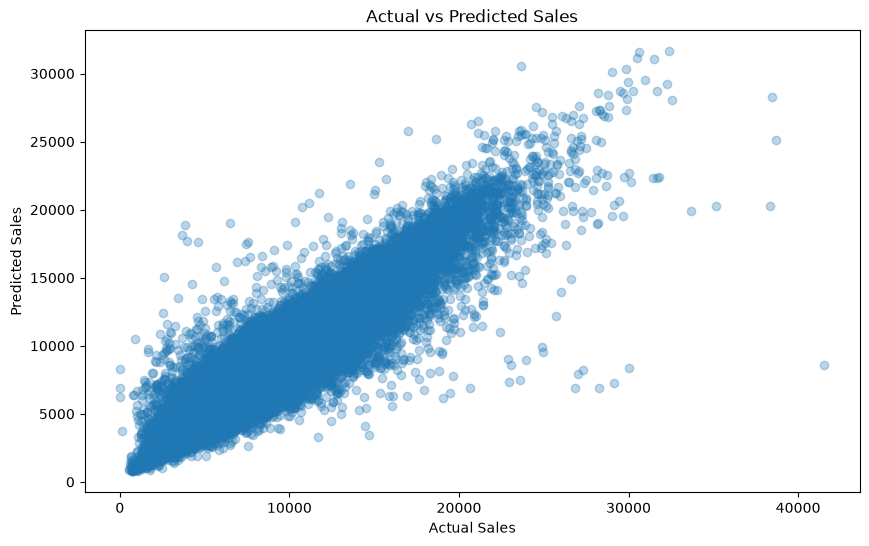

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.savefig("../images/actual_vs_predicted.png", bbox_inches='tight')
plt.show()

## Residual Analysis

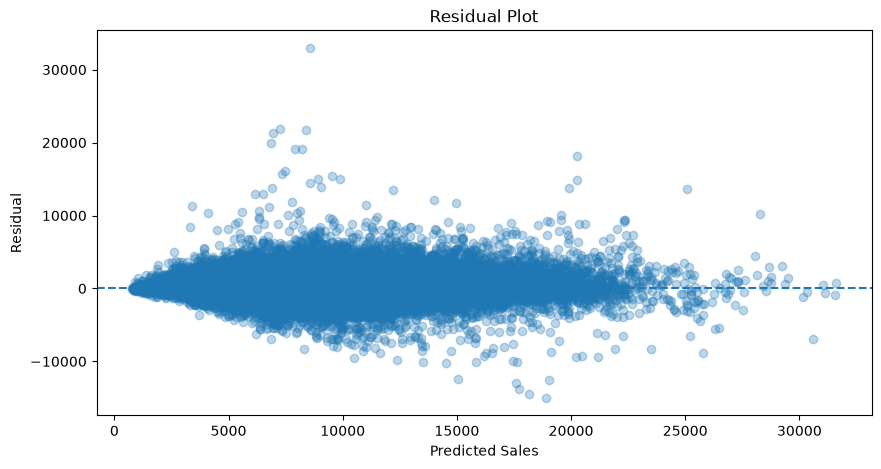

In [45]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_rf, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## Feature Importance

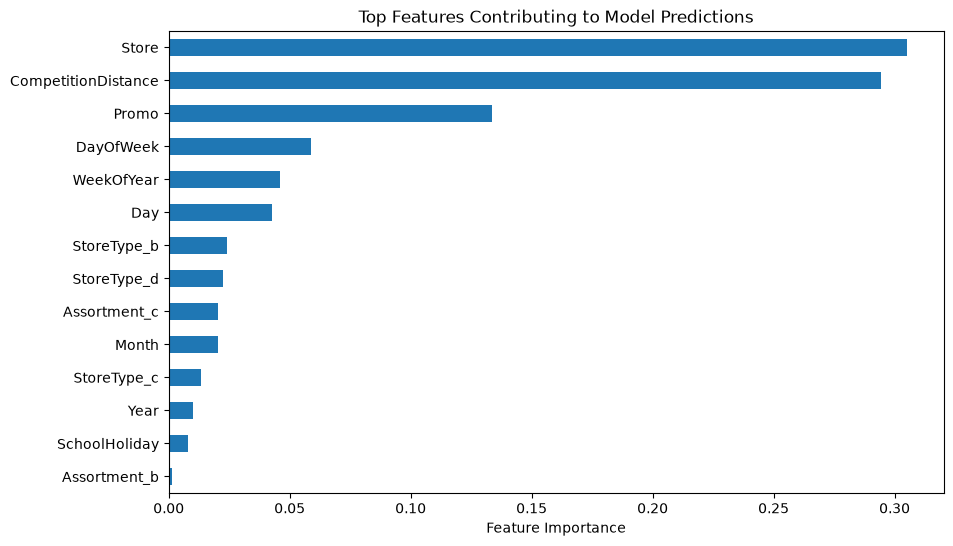

In [46]:
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)
importance.head(15)

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Features Contributing to Model Predictions")
plt.xlabel("Feature Importance")
plt.show()

## Business Insights

1. Sales showed observable variation across time periods, suggesting temporal patterns relevant to demand planning.
2. Promotional and non-promotional periods showed different average observed sales levels.
3. Sales behavior varied across store types, indicating that store-level characteristics may be useful predictive variables.
4. The Random Forest model identified several features that contributed strongly to its predictions.
5. The forecasting approach could potentially support inventory and operational planning by providing estimated future sales.

## Limitations

- The dataset represents historical sales and may not fully represent future market conditions.
- External variables such as weather, local economic conditions, competitor actions, and unexpected events are not fully captured.
- The model predicts sales but does not establish causal relationships.
- Additional lag and rolling-window features could potentially improve the forecasting approach.
- Model performance may vary across individual stores and time periods.

## Future Improvements

- Add lag-based sales features
- Add rolling averages
- Experiment with gradient boosting models
- Perform hyperparameter tuning
- Incorporate additional external variables
- Evaluate models using rolling/expanding time-series validation
- Develop a formal time-series forecasting approach
- Deploy the model through an API
- Build an interactive dashboard